# Backprop Topology Optimization

Use the autograd on a differentiable physics simulation run to optimize topology of a heatsink.

## Motivations

The evolution of a thermal system may is defined by the heat equation:  
`δu/δt = Δu = Σ(n in N) δ²u/δx_n²`  

With:
- `N` as number of dimensions,
- `u` as temperature,
- `t` as time,
- `x_n` as spatial coordinate along one dimension

The general solution to the heat equation in discrete space and time, regressively defined, is:  
`T(t+Δt) = T(t) + Δt * ( L @ T(t) / Δx² + T_f )`, where:
- for a homogenous medium, `L = (W - nD * I)`  
- for a heterogenous medium, `L = W * (0.5 * Ai + Aj)`  

With:
- `n` as the product of dimensions of the simulation space,
- `t` as time,
- `Δt` as timestep,
- `Δx` as cell size (set to `1` in simulation owing to scale invariance),
- `T` (`n` by `1`) as Temperature at each cell,
- `A` (`1` by `n`) as thermal diffusivity at each cell (trainable parameter),
    - `Ai` = `A.view(-1,1).expand(-1, A.size(0))` or A repeated horizontally
    - `Aj` = `A.view(1,-1).expand(A.size(0), -1)` or A repeated vertically
- `W` (`n` by `n`) as the neighbor (adjacency) matrix,  
- `T_f` (`1` by `n`) as the temperature forcing function (ie. rate of thermal energy added/removed) at each cell

This operation may be represented as one layer of a recurrent network.  
The forward propagation of one layer corresponds to the simulation environment progressing by one timestep.  

By using specifications defined about a detector (eg. Temperature of a set of cell), the trainable parameters `A` may be tuned to maximize an objective function via backpropagation.

## Prep

#### Import

In [231]:
import torch
import torch.nn as nn

import numpy as np
import matplotlib.pyplot as plt
from   bitmap import bitmap

import json
import time

#### Parameters

In [232]:
# SIM_DIMS = (3, 3)
SIM_DIMS = (20, 20)

DEVICE = torch.device("cuda") if torch.cuda.is_available() else torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")

### Neighbor Matrix

In [233]:
def neighbor_matrix(dims: tuple):
    n   = np.prod(dims)
    mat = np.zeros(shape=(n, n), dtype=np.uint8)

    nD  = len(dims)
    i   = np.zeros(nD, dtype=np.uint32)

    dim_offsets = np.ones_like(dims, dtype=np.uint32)
    for nd in range(1, nD):
        dim_offsets[nd] *= dims[nd - 1]

    # not_done    = lambda dims, i: np.sum(dims - i) > 0
    done        = False
    get_li      = lambda d_off, i: np.uint32(np.dot(d_off, i))

    # Loop until each cell is exhausted
    while not done:
        # print(f"Cell {i}")
        li = get_li(dim_offsets, i)
        
        # Find neighbors to top-left-up-etc. for each cell
        # And set them to 1 in neighbor matrix
        for nd in range(nD):
            # Skip top-left-upper boundaries
            if i[nd] == 0:
                continue
            
            i_neighbor      = i.copy()
            i_neighbor[nd] -= 1
            li_neighbor     = get_li(dim_offsets, i_neighbor)
            mat[li_neighbor, li] = 1
            # print(f" Neighbor {i_neighbor}")

        for nd in range(nD):
            i[nd] += 1

            if i[nd] < dims[nd]:
                break
            
            if nd == nD - 1:
                done = True
                break

            i[nd] = 0
        
    mat += mat.T

    return mat

In [234]:
def sparse_neighbor_matrix(dims: tuple):
    n    = np.prod(dims, dtype=np.uint32)
    inds = [[], []]

    nD  = len(dims)
    i   = np.zeros(nD, dtype=np.uint32)

    dim_offsets = np.ones_like(dims, dtype=np.uint32)
    for nd in range(1, nD):
        dim_offsets[nd] *= dims[nd - 1]

    # not_done    = lambda dims, i: np.sum(dims - i) > 0
    done        = False
    get_li      = lambda d_off, i: np.uint32(np.dot(d_off, i))

    # Loop until each cell is exhausted
    while not done:
        # print(f"Cell {i}")
        li = get_li(dim_offsets, i)
        
        # Find neighbors to top-left-up-etc. for each cell
        # And set them to 1 in neighbor matrix
        for nd in range(nD):
            # Skip top-left-upper boundaries
            if i[nd] == 0:
                continue
            
            i_neighbor      = i.copy()
            i_neighbor[nd] -= 1
            li_neighbor     = get_li(dim_offsets, i_neighbor)
            inds[0].append(li_neighbor)
            inds[1].append(li)

            # YOU FORGOT THE TRANSPOSE BRUDDUH
            inds[0].append(li)
            inds[1].append(li_neighbor)
            # print(f" Neighbor {i_neighbor}")

        for nd in range(nD):
            i[nd] += 1

            if i[nd] < dims[nd]:
                break
            
            if nd == nD - 1:
                done = True
                break

            i[nd] = 0

    return inds, np.ones(len(inds[0]), dtype=np.uint8), (n, n)

### Identity Matrix
The classic

In [235]:
def identity_matrix(dims):
    return np.identity(np.prod(dims), dtype=np.uint32)

In [236]:
def sparse_identity_matrix(dims):
    n = np.prod(dims)
    return [[i for i in range(n)]] * 2, np.ones(n), (n, n)

Test Hadamard Product

In [237]:
import torch

# Example: Matrix (3x4) and Vector (4)
matrix = torch.ones(3, 4)
vector = torch.randn(1, 4)

# Expand the vector to have a shape compatible with the matrix for broadcasting
# Add a dimension of size 1 at the end: (4,) -> (4, 1)
vector_reshaped = vector#.unsqueeze(-1) # Shape becomes (4, 1)
# Alternatively: vector_reshaped = vector[..., None]

# Perform element-wise multiplication (Hadamard product)
# Broadcasting will occur along the last dimension of the matrix,
# effectively multiplying each row of the matrix by the vector.
# The result will have the same shape as the matrix.
result = matrix * vector_reshaped

print("Matrix shape:", matrix.shape)
print("Vector shape (before reshape):", vector.shape)
print("Vector shape (after reshape):", vector_reshaped.shape)
print("Result shape:", result.shape)
print("Result:\n", result)

Matrix shape: torch.Size([3, 4])
Vector shape (before reshape): torch.Size([1, 4])
Vector shape (after reshape): torch.Size([1, 4])
Result shape: torch.Size([3, 4])
Result:
 tensor([[-0.6718, -0.1516, -0.2473,  0.7997],
        [-0.6718, -0.1516, -0.2473,  0.7997],
        [-0.6718, -0.1516, -0.2473,  0.7997]])


## Define Simulation Space

#### Initialize Geometry

A

In [238]:
A_map = bitmap(SIM_DIMS)
A_map.rect((0, 0), SIM_DIMS, center=False, value=0.1, operation="random")
# A_map.rect((1, 0), (1, 3), center=False,  value=0.9, operation="set")
A_map.rect((10, 10), (5, 20), center=True, value=5, operation="set")
# np.uint8(np.round(A_map.map))
# A_map.map

([np.int64(8), np.int64(0)], [np.int64(12), np.int64(20)])

T

In [239]:
T_map = bitmap(SIM_DIMS)
T_map.rect((0, 0), SIM_DIMS, center=False, value=0, operation="set")

([np.int64(0), np.int64(0)], [np.int64(20), np.int64(20)])

T_f Source

In [240]:
Tf_map = bitmap(SIM_DIMS)
# Tf_map.rect((0, 0), SIM_DIMS, center=False, value=0.1, operation="set")
# Tf_map.rect((1, 0), (1, 1), center=False, value=1, operation="set")
Tf_map.rect((10, 3), (2, 2), center=True, value=1, operation="set")
# Tf_map.rect((10, 17), (5, 2), center=True, value=0.5, operation="set")
# np.uint8(np.round(Tf_map.map))

([np.int64(9), np.int64(2)], [np.int64(11), np.int64(4)])

Detector

In [241]:
D_map = bitmap(SIM_DIMS)
# D_map.rect((1, 2), (1, 1), center=False,  value=1, operation="set")
D_map.rect((10, 20), (5, 2), center=True,  value=1, operation="set")
# np.uint8(np.round(D_map.map))

([np.int64(8), np.int64(19)], [np.int64(12), np.int64(20)])

#### Plot Geometry

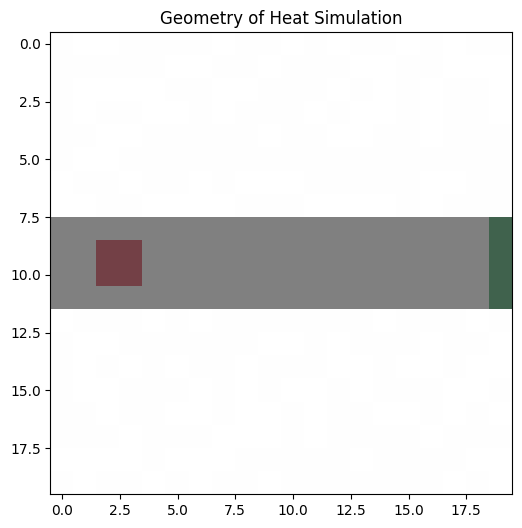

In [242]:
get_alpha = lambda data, top, bottom: (data - bottom) / (top - bottom)
alpha_A   = get_alpha(A_map.map,   1, 0)
alpha_T   = get_alpha(T_map.map,   1, 0)
alpha_Tf  = get_alpha(Tf_map.map,  1, 0)
alpha_D   = get_alpha(D_map.map,   1, 0)

plt.figure(figsize=np.array(SIM_DIMS) * 0.3)
plt.title("Geometry of Heat Simulation")
plt.imshow(A_map.map,  cmap="Greys",  vmin=0, vmax=1, alpha=alpha_A * 0.1,  label="A")
plt.imshow(T_map.map,  cmap="PuRd",   vmin=0, vmax=1, alpha=alpha_T * 0.2,  label="T")
plt.imshow(Tf_map.map, cmap="Reds",   vmin=0, vmax=1, alpha=alpha_Tf * 0.5, label="Tf")
plt.imshow(D_map.map,  cmap="Greens", vmin=0, vmax=1, alpha=alpha_D * 0.5,  label="D")

## Define Model

In [243]:
class HeatTimestep(nn.Module):
    """
    The general solution to the heat equation in discrete space and time, regressively defined, is:  
    `T(t+Δt) = T(t) + Δt * ( L @ T(t) / Δx² + T_f )`, where:
    - for a homogenous medium, `L = (W - nD * I)`  
    - for a heterogenous medium, `L = W * (0.5 * Ai + Aj)`  
    """
    def __init__(self, num_dims, Δt, W_sparse, A, I_sparse, T_f):
        super(HeatTimestep, self).__init__()

        # Assumed for spatial invariance, not used in sim
        self.Δx  = 1

        self.nD  = num_dims
        self.Δt  = Δt
        self.W   = torch.sparse_coo_tensor(W_sparse[0], W_sparse[1], W_sparse[2], dtype=torch.float32, device=DEVICE)    # Ind, Val, Dim
        self.A   = nn.Parameter(torch.tensor(A, dtype=torch.float32, device=DEVICE))                                     # Requires shape=(1, n)
        self.I   = torch.sparse_coo_tensor(I_sparse[0], I_sparse[1], I_sparse[2], dtype=torch.float32, device=DEVICE)
        self.T_f = torch.tensor(T_f, dtype=torch.float32, device=DEVICE) if T_f is not None else None                    # Shape=(n, 1)
        
    def reset_parameters(self):
        """
        Call after backprop
        """
        del self.G
        del self.P
        del self.L

    def update_parameters(self):
        """
        Call before each run when A changes
        """
        # G = Heat flux In, P = Heat flux Out, per unit time, per temperature difference
        self.G   = 0.5 * (self.W * self.A.view(-1,1) + self.W * self.A.view(1, -1))     # Build symmetric conductance matrix G where G_ij = (A_i + A_j)/2 if neighbors
        self.P   = self.I * self.G.sum(dim=1).values()                                  # Set magnitude of heat out equal to magnitude of heat in.
        self.L   = -self.P + self.G                                                     # Set heat out = -heat in

    def forward(self, T):
        """
        One timestep
        """
        if not hasattr(self, "L"):
            self.update_parameters()

        L = self.L
        # Explicit update: T_new = T + dt * (L @ T) / dx^2 + dt*T_f
        T_new = T + self.Δt * (L @ T) # / (self.Δx*self.Δx)
        if self.T_f is not None:
            T_new = T_new + self.Δt * self.T_f.view(-1)
        return T_new


## Simulate!

#### Format Data for Model

In [244]:
tF          = 200

Δt          = 0.05
W_sparse    = sparse_neighbor_matrix(SIM_DIMS)
A           = A_map.flatten_hoz()
I_sparse    = sparse_identity_matrix(SIM_DIMS)
T_f         = Tf_map.flatten_ver()

T0          = torch.tensor(T_map.flatten_ver(), dtype=torch.float32, device=DEVICE)

##### Debug

In [245]:
s = {}

s["Δt"]  = Δt
s["W"]   = torch.sparse_coo_tensor(W_sparse[0], W_sparse[1], W_sparse[2], dtype=torch.float32, device=DEVICE)    # Ind, Val, Dim
s["A"]   = nn.Parameter(torch.tensor(A, dtype=torch.float32, device=DEVICE))                                     # Requires shape=(1, n)
s["I"]   = torch.sparse_coo_tensor(I_sparse[0], I_sparse[1], I_sparse[2], dtype=torch.float32, device=DEVICE)
s["T_f"] = torch.tensor(T_f, dtype=torch.float32, device=DEVICE)                                                 # Shape=(n, 1)

### Create Model

In [246]:
step = HeatTimestep(len(SIM_DIMS), Δt, W_sparse, A, I_sparse, None)

##### Debug

In [247]:
I = step.I
G = 0.5 * (step.W * step.A.view(-1,1) + step.W * step.A.view(1, -1))

In [248]:
# G = step.G.to_dense().detach().numpy()
# with open("G_dump", "w") as Dump:
#     for row in G:
#         Dump.write(json.dumps(row.tolist()))
#         Dump.write("\n")

In [249]:
# P = step.P.to_dense().detach().numpy()
# with open("P_dump", "w") as Dump:
#     for row in P:
#         Dump.write(json.dumps(row.tolist()))
#         Dump.write("\n")

### Run Model Iteratively from T0 to TF

In [250]:
T_hist = []
T      = torch.max(T0, s["T_f"])

t = 0
while t < tF:
    T = torch.max(T, s["T_f"])
    T = step.forward(T)
    T_hist.append(T.detach().cpu().numpy().reshape(SIM_DIMS))

    t += Δt

### Log Sim Results for Visualization

In [251]:
with open("sim_results.json", "w") as res:
    res.write(json.dumps(np.array(T_hist).tolist()))

### Ensure no Blowups

In [252]:
len(T_hist)

4000

In [253]:
[np.max(x) for x in T_hist[0:10]]

[np.float32(0.5),
 np.float32(0.625),
 np.float32(0.6639855),
 np.float32(0.6971384),
 np.float32(0.7185502),
 np.float32(0.73652697),
 np.float32(0.75155795),
 np.float32(0.7647755),
 np.float32(0.776617),
 np.float32(0.7873599)]

In [254]:
[np.max(x) for x in T_hist[-10:]]

[np.float32(0.9976817),
 np.float32(0.9976821),
 np.float32(0.9976824),
 np.float32(0.9976828),
 np.float32(0.99768317),
 np.float32(0.99768347),
 np.float32(0.9976839),
 np.float32(0.99768424),
 np.float32(0.99768454),
 np.float32(0.99768496)]

In [255]:
np.isnan(T_hist)

array([[[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]],

       [[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]],

       [[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, Fal